# 01 — Preprocessing

Reads raw Phyphox exports, trims to 180 s, standardises format, assigns `session_1` / `session_2`.

Output: `cleaned_data/`

In [1]:
import shutil
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('.').resolve()
ML4QS_CODE = ROOT.parent / 'ML4QS' / 'Python3Code'
if str(ML4QS_CODE) not in sys.path:
    sys.path.insert(0, str(ML4QS_CODE))

from Chapter3.OutlierDetection import DistributionBasedOutlierDetection
from Chapter3.ImputationMissingValues import ImputationMissingValues

OUT = ROOT / 'cleaned_data'
DURATION_S = 180.0
MIN_DURATION_S = 175.0
COLS = ['time_acc', 'acc_x', 'acc_y', 'acc_z', 'time_gyro', 'gyro_x', 'gyro_y', 'gyro_z']
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
CHAUENET_C = 1.5  # selected via Chauvenet sensitivity (fig6c): removes ~52 m/s² spikes, keeps gait peaks
MIN_DURATION_CROWDED_S = 160.0  # allow slightly short crowded re-records (e.g. Ana ~164 s)
INCLUDE_PARTICIPANTS = {'Pedro', 'Jun', 'Darius', 'Oana'}  # normal walking
INCLUDE_CROWDED = {'Ana', 'Pedro', 'Jun', 'Darius', 'Asena', 'Oana'}  # crowded walking
TRIM_WINDOW = {}  # no recordings need manual trimming
C_SENSITIVITY = [1.5, 2.0, 2.5, 3.0]
AXIS_LABELS = {
    'acc_x': 'Lateral acceleration (m/s²)',
    'acc_y': 'Vertical acceleration (m/s²)',
    'acc_z': 'Forward acceleration (m/s²)',
    'gyro_x': 'Roll rate (rad/s)',
    'gyro_y': 'Pitch rate (rad/s)',
    'gyro_z': 'Yaw rate (rad/s)',
}

## Load helpers

In [2]:
def load_gait(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=['time_acc'])
    return df


def load_separated(folder):
    """Load recordings stored as separate Accelerometer.csv + Gyroscope.csv files."""
    acc = pd.read_csv(folder / 'Accelerometer.csv').rename(columns={
        'Time (s)': 'time_acc', 'X (m/s^2)': 'acc_x',
        'Y (m/s^2)': 'acc_y', 'Z (m/s^2)': 'acc_z'})
    gyr = pd.read_csv(folder / 'Gyroscope.csv').rename(columns={
        'Time (s)': 'time_gyro', 'X (rad/s)': 'gyro_x',
        'Y (rad/s)': 'gyro_y', 'Z (rad/s)': 'gyro_z'})
    return pd.concat([acc, gyr], axis=1)


def recording_date(folder):
    meta = folder / 'meta' / 'time.csv'
    if not meta.exists():
        return folder.name
    m = pd.read_csv(meta)
    row = m.loc[m['event'] == 'START', 'system time text']
    return row.iloc[0] if len(row) else folder.name


def duration(df):
    return float(df['time_acc'].iloc[-1] - df['time_acc'].iloc[0])


def trim_window(df, start, end):
    acc = df.loc[(df['time_acc'] >= start) & (df['time_acc'] <= end),
                 ['time_acc', 'acc_x', 'acc_y', 'acc_z']].copy()
    gyr = df.loc[(df['time_gyro'] >= start) & (df['time_gyro'] <= end),
                 ['time_gyro', 'gyro_x', 'gyro_y', 'gyro_z']].copy()
    n = min(len(acc), len(gyr))
    acc = acc.iloc[:n].reset_index(drop=True)
    gyr = gyr.iloc[:n].reset_index(drop=True)
    t0 = acc['time_acc'].iloc[0]
    acc['time_acc'] -= t0
    gyr['time_gyro'] -= t0
    return pd.concat([acc, gyr], axis=1)


def trim_first(df, seconds=DURATION_S):
    t0 = df['time_acc'].iloc[0]
    return trim_window(df, t0, t0 + seconds)


_outlier_distr = DistributionBasedOutlierDetection()
_impute = ImputationMissingValues()


def apply_chauvenet(df, cols=None, C=CHAUENET_C):
    """Chauvenet outlier detection (ML4QS Ch.3). Nulls flagged values; returns any-axis mask."""
    cols = cols or SENSOR_COLS
    out = df[COLS].copy()
    any_outlier = np.zeros(len(out), dtype=bool)
    for col in cols:
        out = _outlier_distr.chauvenet(out, col, C)
        flagged = out[f'{col}_outlier'].astype(bool)
        any_outlier |= flagged.values
        out.loc[flagged, col] = np.nan
        del out[f'{col}_outlier']
    return out, any_outlier


def clean_sensor(df, C=CHAUENET_C):
    """Chauvenet per sensor axis, then linear interpolation imputation (ML4QS Ch.3)."""
    out, _ = apply_chauvenet(df, C=C)
    for col in SENSOR_COLS:
        out = _impute.impute_interpolate(out, col)
    return out.reset_index(drop=True)


def chauvenet_counts(df, C):
    """Outlier count per axis (independent Chauvenet pass per column)."""
    od = DistributionBasedOutlierDetection()
    base = df[COLS].copy()
    return {
        col: int(od.chauvenet(base.copy(), col, C)[f'{col}_outlier'].sum())
        for col in SENSOR_COLS
    }


def load_trimmed_recording(row):
    """Reload trimmed but uncleaned recording from a manifest row."""
    source, action = row['source'], row['action']
    source_path = ROOT / source
    if (source_path / 'Accelerometer.csv').exists():
        df = load_separated(source_path)
    else:
        df = load_gait(source_path / 'Gait Data.csv')
    if source in TRIM_WINDOW:
        s, e = TRIM_WINDOW[source]
        return trim_window(df, s, e)
    if 'trim' in action and action != 'trim_window':
        return trim_first(df)
    return df[COLS].copy()

## Raw inventory

In [3]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana\Crowded\AnaCrowded1,180.0
1,Ana\Crowded\AnaCrowded2,69.0
2,Ana\Crowded\AnaCrowded3,163.7
3,Asena\Crowded\AsenaCrowded1,180.0
4,Asena\Crowded\AsenaCrowded2,180.0
5,Darius\Crowded\DariusCrowded1,175.5
6,Darius\Crowded\DariusCrowded2,355.6
16,Darius\DariusUni1,180.0
17,Darius\DariusUni2,180.0
18,Darius\DariusUni3,180.0


## Clean recordings

- `tryLengthenData` and short crowded files skipped
- long files trimmed to first 180 s
- Chauvenet outlier removal + interpolation imputation per axis (`crowdsignals_ch3_outliers.py`; $C$ chosen via sensitivity analysis)
- sessions renamed `session_1` / `session_2` by recording date

In [6]:
SKIP_PATHS = {
    'Pedro/Crowded/PedroCrowded2',  # short recording (128 s), replaced by PedroCrowded3
}

pending = []


def queue(participant, context, source_folder, df, action):
    cleaned = clean_sensor(df)
    pending.append({
        'participant': participant,
        'context': context,
        'source_folder': source_folder,
        'recording_date': recording_date(ROOT / source_folder) if (ROOT / source_folder).exists() else source_folder,
        'df': cleaned,
        'action': action,
        'duration_s': round(duration(cleaned), 1),
    })


def process_df(df, rel, context='normal'):
    if rel in TRIM_WINDOW:
        s, e = TRIM_WINDOW[rel]
        return trim_window(df, s, e), 'trim_window'
    d = duration(df)
    min_d = MIN_DURATION_CROWDED_S if context == 'crowded' else MIN_DURATION_S
    if d < min_d:
        return None, 'skip_short'
    if d > DURATION_S + 2:
        return trim_first(df), 'trim'
    return df[COLS], 'copy'

# Recordings stored as separate Accelerometer.csv + Gyroscope.csv (Uni sessions)
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    folder = path.parent
    rel = folder.relative_to(ROOT).as_posix()
    participant = rel.split('/')[0]
    if participant not in INCLUDE_PARTICIPANTS or rel in SKIP_PATHS:
        continue
    context = 'crowded' if any(p.lower() == 'crowded' for p in path.parts) else 'normal'
    df, action = process_df(load_separated(folder), rel, context)
    if df is not None:
        queue(participant, context, rel, df, 'merge_' + action)

# Recordings stored as merged Gait Data.csv (e.g. Jun Uni2/Uni3, all crowded sessions)
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if any(x in path.parts for x in ['cleaned_data', 'windowed_data']):
        continue
    rel = path.parent.relative_to(ROOT).as_posix()
    participant = rel.split('/')[0]
    is_crowded = any(p.lower() == 'crowded' for p in path.parts)
    include_set = INCLUDE_CROWDED if is_crowded else INCLUDE_PARTICIPANTS
    if participant not in include_set or rel in SKIP_PATHS:
        continue
    context = 'crowded' if is_crowded else 'normal'
    df, action = process_df(load_gait(path), rel, context)
    if df is not None:
        queue(participant, context, rel, df, action)

len(pending)

24

In [7]:
if OUT.exists():
    shutil.rmtree(OUT)

manifest = []
pending_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'df'} for r in pending])

for (participant, context), grp in pending_df.groupby(['participant', 'context']):
    order = grp.sort_values('recording_date').index.tolist()
    for rank, idx in enumerate(order, start=1):
        item = pending[idx]
        session = f'session_{rank}'
        folder = OUT / participant / context / session
        folder.mkdir(parents=True, exist_ok=True)
        item['df'].to_csv(folder / 'Gait Data.csv', index=False)
        manifest.append({
            'participant': participant,
            'context': context,
            'session': session,
            'source': item['source_folder'],
            'action': item['action'],
            'duration_s': item['duration_s'],
            'recording_date': item['recording_date'],
        })

manifest_df = pd.DataFrame(manifest).sort_values(['participant', 'context', 'session'])
# cross-session = has both session_1 and session_2 for normal walking
normal_counts = manifest_df[manifest_df['context'] == 'normal'].groupby('participant')['session'].nunique()
eligible = set(normal_counts[normal_counts >= 2].index)
manifest_df['cross_session_eligible'] = (manifest_df['context'] == 'normal') & manifest_df['participant'].isin(eligible)
manifest_df.to_csv(OUT / 'manifest.csv', index=False)
manifest_df

,participant,context,session,source,action,duration_s,recording_date,cross_session_eligible
0,Ana,crowded,session_1,Ana/Crowded/AnaCrowded1,copy,180.0,2026-06-06 20:06:36.409 UTC+02:00,False
1,Ana,crowded,session_2,Ana/Crowded/AnaCrowded3,copy,163.7,2026-06-07 19:48:36.492 UTC+02:00,False
2,Asena,crowded,session_1,Asena/Crowded/AsenaCrowded1,copy,180.0,2026-06-06 15:36:27.123 UTC+02:00,False
3,Asena,crowded,session_2,Asena/Crowded/AsenaCrowded2,copy,180.0,2026-06-06 16:24:41.684 UTC+02:00,False
4,Darius,crowded,session_1,Darius/Crowded/DariusCrowded1,copy,175.5,2026-06-06 17:29:44.172 UTC+02:00,False
5,Darius,crowded,session_2,Darius/Crowded/DariusCrowded2,trim,180.0,2026-06-06 17:29:44.172 UTC+02:00,False
6,Darius,normal,session_1,Darius/DariusUni1,merge_copy,180.0,2026-06-13 15:48:00.311 UTC+02:00,True
7,Darius,normal,session_2,Darius/DariusUni2,merge_copy,180.0,2026-06-13 15:51:35.453 UTC+02:00,True
8,Darius,normal,session_3,Darius/DariusUni3,merge_copy,180.0,2026-06-13 15:55:11.037 UTC+02:00,True
9,Jun,crowded,session_1,Jun/Crowded/JunCrowded1,copy,180.0,2026-06-06 15:36:26.892 UTC+02:00,False


## Verify durations

In [8]:
check = manifest_df[['participant', 'context', 'session', 'duration_s', 'cross_session_eligible']]
bad = check[check['duration_s'] < MIN_DURATION_S]
print(f'Participants: {manifest_df.participant.nunique()}')
print(f'Cross-session eligible (2 normal sessions):')
print(manifest_df[(manifest_df.context=='normal') & (manifest_df.session=='session_2')].participant.nunique())
if len(bad):
    display(bad)
check

Participants: 6
Cross-session eligible (2 normal sessions):
4


,participant,context,session,duration_s,cross_session_eligible
1,Ana,crowded,session_2,163.7,False


,participant,context,session,duration_s,cross_session_eligible
0,Ana,crowded,session_1,180.0,False
1,Ana,crowded,session_2,163.7,False
2,Asena,crowded,session_1,180.0,False
3,Asena,crowded,session_2,180.0,False
4,Darius,crowded,session_1,175.5,False
5,Darius,crowded,session_2,180.0,False
6,Darius,normal,session_1,180.0,True
7,Darius,normal,session_2,180.0,True
8,Darius,normal,session_3,180.0,True
9,Jun,crowded,session_1,180.0,False


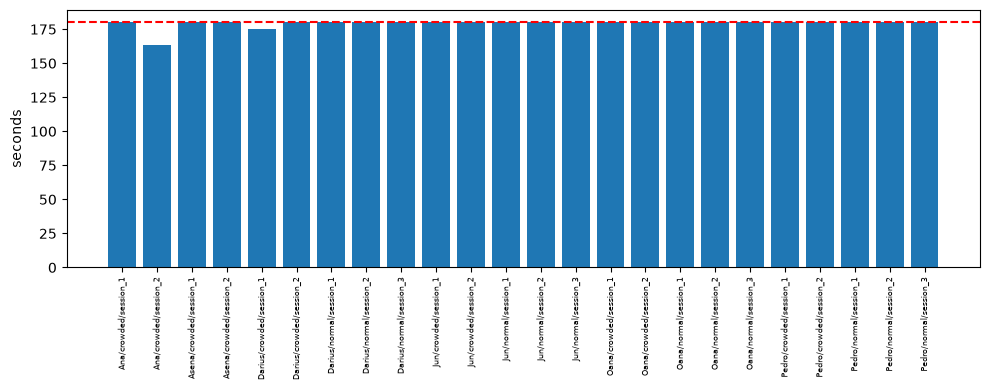

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
labels = manifest_df['participant'] + '/' + manifest_df['context'] + '/' + manifest_df['session']
ax.bar(range(len(manifest_df)), manifest_df['duration_s'])
ax.axhline(DURATION_S, color='red', linestyle='--')
ax.set_xticks(range(len(manifest_df)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel('seconds')
fig.tight_layout()
plt.show()

## Report figures

**Run the cleaning cell above first** so `cleaned_data/` matches `CHAUENET_C`.

Saves plots to `figures/` for the report, including:
- Chauvenet $C$ sensitivity analysis (ML4QS Ch.3)
- Per-participant EDA (inter-individual + cross-session stability)
- Six-axis comparison to justify vertical acceleration for gait visualization

In [10]:
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
manifest = pd.read_csv(OUT / 'manifest.csv')
display_labels = [AXIS_LABELS[c] for c in SENSOR_COLS]


def boxplot_axes(ax, df, title):
    ax.boxplot([df[c].dropna() for c in SENSOR_COLS], tick_labels=display_labels)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    ax.set_ylabel('Sensor value')


# --- Chauvenet C sensitivity (all recordings) ---
trimmed_cache = {i: load_trimmed_recording(row) for i, row in manifest.iterrows()}
sensitivity_rows = []
for C in C_SENSITIVITY:
    for i, row in manifest.iterrows():
        counts = chauvenet_counts(trimmed_cache[i], C)
        for col, n in counts.items():
            sensitivity_rows.append({
                'C': C, 'participant': row['participant'], 'context': row['context'],
                'session': row['session'], 'axis': col, 'n_outliers': n,
                'pct_outliers': 100 * n / len(trimmed_cache[i]),
            })
sensitivity_df = pd.DataFrame(sensitivity_rows)
summary = sensitivity_df.groupby(['C', 'axis'], as_index=False).agg(
    total_outliers=('n_outliers', 'sum'),
    mean_pct=('pct_outliers', 'mean'),
    max_pct=('pct_outliers', 'max'),
)
summary['axis_label'] = summary['axis'].map(AXIS_LABELS)
summary.to_csv(FIG_DIR / 'chauvenet_sensitivity_summary.csv', index=False)
sensitivity_df.to_csv(FIG_DIR / 'chauvenet_sensitivity_per_recording.csv', index=False)
print('Chauvenet outlier counts (total samples flagged, all recordings):')
print(summary.pivot(index='axis', columns='C', values='total_outliers').astype(int))

fig, ax = plt.subplots(figsize=(9, 4))
pivot = summary.pivot(index='axis_label', columns='C', values='total_outliers')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Chauvenet outliers flagged by C and axis (all recordings)')
ax.set_ylabel('Total flagged samples')
ax.set_xlabel('')
ax.legend(title='C')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6_chauvenet_counts_by_C.png', dpi=150)
plt.close(fig)

# Before/after boxplots per C (Pedro normal session 2 as reference recording)
ref_row = manifest[(manifest.participant == 'Pedro') & (manifest.context == 'normal') & (manifest.session == 'session_2')].iloc[0]
raw_ref = load_trimmed_recording(ref_row)
fig, axes = plt.subplots(len(C_SENSITIVITY), 2, figsize=(12, 3 * len(C_SENSITIVITY)))
for r, C in enumerate(C_SENSITIVITY):
    cleaned = clean_sensor(raw_ref, C=C)
    boxplot_axes(axes[r, 0], raw_ref, f'Before cleaning (C={C})')
    boxplot_axes(axes[r, 1], cleaned, f'After Chauvenet + imputation (C={C})')
fig.suptitle('Per-axis distributions: Pedro normal session 2', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6b_chauvenet_boxplot_by_C.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# Max absolute acceleration after cleaning — guides C choice
spike_rows = []
for C in C_SENSITIVITY:
    cleaned = clean_sensor(raw_ref, C=C)
    for col in ['acc_x', 'acc_y', 'acc_z']:
        spike_rows.append({
            'C': C, 'axis': col,
            'max_abs_before': raw_ref[col].abs().max(),
            'max_abs_after': cleaned[col].abs().max(),
            'p99_before': raw_ref[col].abs().quantile(0.99),
            'p99_after': cleaned[col].abs().quantile(0.99),
        })
spike_df = pd.DataFrame(spike_rows)
spike_df.to_csv(FIG_DIR / 'chauvenet_spike_comparison.csv', index=False)
print('\nPeak amplitudes on Pedro normal session 2 (hardware spikes vs gait peaks):')
print(spike_df.pivot(index='axis', columns='C', values='max_abs_after').round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for col in ['acc_x', 'acc_y', 'acc_z']:
    sub = spike_df[spike_df.axis == col]
    ax.plot(sub['C'], sub['max_abs_after'], marker='o', label=AXIS_LABELS[col])
ax.axhline(30, color='green', ls='--', alpha=0.6, label='Typical gait peak (~30 m/s²)')
ax.axhline(50, color='red', ls='--', alpha=0.6, label='Suspected hardware spike (~50 m/s²)')
ax.set_xlabel('Chauvenet C')
ax.set_ylabel('Max |acceleration| after cleaning (m/s²)')
ax.set_title('Choosing C: suppress spikes while keeping gait amplitude')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig6c_chauvenet_C_selection.png', dpi=150)
plt.close(fig)

# --- Fig 1: person-specific gait (vertical acceleration) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, person in zip(axes, ['Pedro', 'Jun', 'Oana']):
    df = pd.read_csv(OUT / person / 'normal' / 'session_1' / 'Gait Data.csv')
    m = df['time_acc'] <= 20
    ax.plot(df.loc[m, 'time_acc'], df.loc[m, 'acc_y'])
    ax.set_ylabel(AXIS_LABELS['acc_y'])
    ax.set_title(person)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Person-specific gait patterns (normal walking, session 1, first 20 s)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_eda_gait_patterns.png', dpi=150)
plt.close(fig)


# --- Fig 3: outlier example at chosen C ---
raw_fig3 = load_trimmed_recording(ref_row)
_, outlier_mask = apply_chauvenet(raw_fig3, cols=['acc_y'], C=CHAUENET_C)
cleaned_fig3 = clean_sensor(raw_fig3, C=CHAUENET_C)
zoom = raw_fig3['time_acc'] <= 15
out_zoom = outlier_mask & zoom
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(raw_fig3.loc[zoom, 'time_acc'], raw_fig3.loc[zoom, 'acc_y'], label='Signal')
axes[0].scatter(raw_fig3.loc[out_zoom, 'time_acc'], raw_fig3.loc[out_zoom, 'acc_y'],
                color='red', s=12, label='Chauvenet outliers')
axes[0].set_ylabel(AXIS_LABELS['acc_y'])
axes[0].set_title(f'Before outlier removal (Chauvenet, C={CHAUENET_C})')
axes[0].legend()
axes[1].plot(cleaned_fig3.loc[cleaned_fig3['time_acc'] <= 15, 'time_acc'],
             cleaned_fig3.loc[cleaned_fig3['time_acc'] <= 15, 'acc_y'])
axes[1].set_title('After Chauvenet + interpolation imputation')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel(AXIS_LABELS['acc_y'])
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_outliers_before_after.png', dpi=150)
plt.close(fig)

# --- Fig 4: global before/after at chosen C ---
clean_pedro = clean_sensor(raw_ref, C=CHAUENET_C)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
boxplot_axes(axes[0], raw_ref, 'Before cleaning')
boxplot_axes(axes[1], clean_pedro, f'After cleaning (C={CHAUENET_C})')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_boxplot_before_after.png', dpi=150)
plt.close(fig)

# --- Fig 5: normal vs crowded ---
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, ctx in zip(axes, ['normal', 'crowded']):
    df = pd.read_csv(OUT / 'Pedro' / ctx / 'session_1' / 'Gait Data.csv')
    m = df['time_acc'] <= 20
    ax.plot(df.loc[m, 'time_acc'], df.loc[m, 'acc_y'])
    ax.set_title(f'Pedro — {ctx} walking')
    ax.set_ylabel(AXIS_LABELS['acc_y'])
axes[-1].set_xlabel('Time (s)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_normal_vs_crowded.png', dpi=150)
plt.close(fig)

# --- Fig 7: per-participant vertical acceleration (normal, both sessions) ---
normal_manifest = manifest[manifest.context == 'normal'].sort_values(['participant', 'session'])
participants = sorted(normal_manifest.participant.unique())
n_p = len(participants)
ncols, nrows = 4, int(np.ceil(n_p / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, person in zip(axes, participants):
    data, labels = [], []
    for session in ['session_1', 'session_2', 'session_3']:
        path = OUT / person / 'normal' / session / 'Gait Data.csv'
        if path.exists():
            data.append(pd.read_csv(path)['acc_y'].dropna())
            labels.append(session.replace('_', ' '))
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(person)
    ax.set_ylabel(AXIS_LABELS['acc_y'])
for ax in axes[len(participants):]:
    ax.axis('off')
fig.suptitle('Per-participant vertical acceleration (normal walking, cross-session comparison)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_per_participant_acc_y.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Fig 8: per-participant yaw rate ---
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.8 * nrows))
axes = np.array(axes).reshape(-1)
for ax, person in zip(axes, participants):
    data, labels = [], []
    for session in ['session_1', 'session_2', 'session_3']:
        path = OUT / person / 'normal' / session / 'Gait Data.csv'
        if path.exists():
            data.append(pd.read_csv(path)['gyro_z'].dropna())
            labels.append(session.replace('_', ' '))
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(person)
    ax.set_ylabel(AXIS_LABELS['gyro_z'])
for ax in axes[len(participants):]:
    ax.axis('off')
fig.suptitle('Per-participant yaw rate (normal walking, cross-session comparison)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig8_per_participant_gyro_z.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# --- Fig 9: all six axes — Pedro session 1, first 20 s ---
df6 = pd.read_csv(OUT / 'Pedro' / 'normal' / 'session_1' / 'Gait Data.csv')
m = df6['time_acc'] <= 20
t = df6.loc[m, 'time_acc']
fig, axes = plt.subplots(6, 1, figsize=(10, 10), sharex=True)
for ax, col in zip(axes, SENSOR_COLS):
    ax.plot(t, df6.loc[m, col])
    ax.set_ylabel(AXIS_LABELS[col], fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('All sensor axes during first 20 s (Pedro, normal session 1)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig9_six_axis_comparison.png', dpi=150)
plt.close(fig)

# Periodicity proxy: autocorrelation at lag ~1 s (stride)
periodicity_rows = []
print('\nStride periodicity (lag-100 correlation, higher = clearer step cycle):')
for col in SENSOR_COLS:
    x = df6.loc[m, col].to_numpy()
    x = x - x.mean()
    corr = np.correlate(x, x, mode='full')
    lag100 = corr[len(x) - 1 + 100] / corr[len(x) - 1]
    periodicity_rows.append({'axis': col, 'axis_label': AXIS_LABELS[col], 'lag100_corr': lag100})
    print(f'  {AXIS_LABELS[col]}: {lag100:.3f}')
pd.DataFrame(periodicity_rows).to_csv(FIG_DIR / 'axis_periodicity_pedro.csv', index=False)

print(f'\nSelected Chauvenet C={CHAUENET_C} for pipeline (see fig6c and chauvenet_spike_comparison.csv)')
print('Saved to', FIG_DIR)


Chauvenet outlier counts (total samples flagged, all recordings):
C        1.5   2.0  2.5  3.0
axis                        
acc_x   1181   282   92   36
acc_y   3227  1470  650  307
acc_z   3327   958  245   62
gyro_x    11     0    0    0
gyro_y   430    99   30   11
gyro_z   206    55   19    9

Peak amplitudes on Pedro normal session 2 (hardware spikes vs gait peaks):
C       1.5   2.0   2.5   3.0
axis                         
acc_x  14.9  17.0  18.8  19.1
acc_y  27.2  30.3  32.9  35.4
acc_z  16.4  19.1  21.3  22.6

Stride periodicity (lag-100 correlation, higher = clearer step cycle):
  Lateral acceleration (m/s²): -0.188
  Vertical acceleration (m/s²): 0.019
  Forward acceleration (m/s²): -0.286
  Roll rate (rad/s): 0.302
  Pitch rate (rad/s): 0.071
  Yaw rate (rad/s): 0.205

Selected Chauvenet C=1.5 for pipeline (see fig6c and chauvenet_spike_comparison.csv)
Saved to C:\Users\Jun\Documents\ML4QS\Experiment\figures


In [11]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana\Crowded\AnaCrowded1,180.0
1,Ana\Crowded\AnaCrowded2,69.0
2,Ana\Crowded\AnaCrowded3,163.7
3,Asena\Crowded\AsenaCrowded1,180.0
4,Asena\Crowded\AsenaCrowded2,180.0
5,Darius\Crowded\DariusCrowded1,175.5
6,Darius\Crowded\DariusCrowded2,355.6
16,Darius\DariusUni1,180.0
17,Darius\DariusUni2,180.0
18,Darius\DariusUni3,180.0


In [12]:
rows = []
for path in sorted(ROOT.rglob('Gait Data.csv')):
    if 'cleaned_data' in path.parts or 'windowed_data' in path.parts:
        continue
    df = load_gait(path)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
for path in sorted(ROOT.rglob('Accelerometer.csv')):
    if 'cleaned_data' in path.parts:
        continue
    df = load_separated(path.parent)
    rows.append({'path': str(path.parent.relative_to(ROOT)), 'duration_s': round(duration(df), 1)})
import pandas as pd
pd.DataFrame(rows).sort_values('path')

,path,duration_s
0,Ana\Crowded\AnaCrowded1,180.0
1,Ana\Crowded\AnaCrowded2,69.0
2,Ana\Crowded\AnaCrowded3,163.7
3,Asena\Crowded\AsenaCrowded1,180.0
4,Asena\Crowded\AsenaCrowded2,180.0
5,Darius\Crowded\DariusCrowded1,175.5
6,Darius\Crowded\DariusCrowded2,355.6
16,Darius\DariusUni1,180.0
17,Darius\DariusUni2,180.0
18,Darius\DariusUni3,180.0
